In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)

In [11]:
df = pd.read_csv("../data/raw/trips.csv", parse_dates=["request_timestamp"])
print(f"Total trips: {len(df):,}")
df.head()

Total trips: 2,000,000


,trip_id,driver_id,rider_id,vehicle_type,payment_method,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon,trip_duration_sec,base_fare_usd,surge_multiplier,request_timestamp,status,fraud_label
0,TRIP-0000000,DRV-02688,RDR-030312,UberX,wallet,40.642273,-74.202218,40.672971,-74.219913,1580,40.76,1.0,2024-02-23 16:52:14,completed,none
1,TRIP-0000001,DRV-03426,RDR-027431,UberX,wallet,40.895904,-74.092449,40.868024,-74.044012,1775,11.66,1.0,2024-02-05 00:58:13,completed,none
2,TRIP-0000002,DRV-02465,RDR-025772,UberXL,cash,40.799624,-73.903447,40.753118,-73.943274,222,25.93,1.0,2024-03-30 08:37:20,completed,none
3,TRIP-0000003,DRV-02511,RDR-031548,UberXL,wallet,40.740929,-74.015691,40.695153,-74.012405,819,29.99,1.0,2024-01-27 10:28:33,completed,none
4,TRIP-0000004,DRV-03138,RDR-029582,Bolt,card,40.546079,-74.135863,40.583075,-74.096288,2988,28.45,1.0,2024-02-28 14:55:16,completed,none


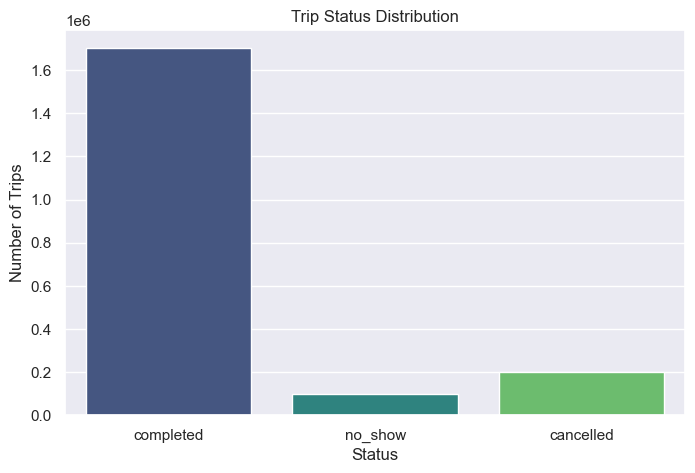

In [12]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='status', hue='status', palette='viridis', legend=False)
plt.title('Trip Status Distribution')
plt.xlabel('Status')
plt.ylabel('Number of Trips')
plt.show()

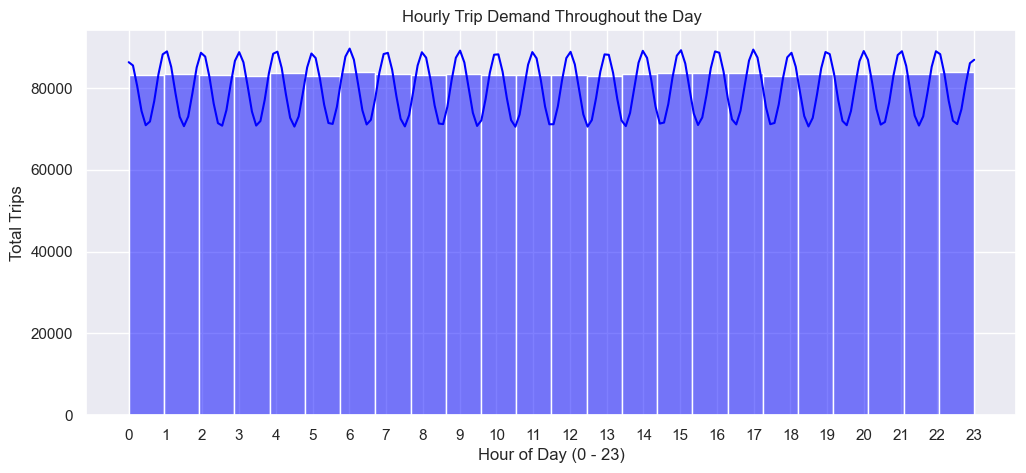

In [13]:
if 'hour' not in df.columns:
    df['hour'] = df['request_timestamp'].dt.hour

plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='hour', bins=24, kde=True, color='blue')
plt.title('Hourly Trip Demand Throughout the Day')
plt.xlabel('Hour of Day (0 - 23)')
plt.ylabel('Total Trips')
plt.xticks(range(0, 24))
plt.show()

Raw Fraud Label Counts:
fraud_label
none             1940000
speed_anomaly      30000
ghost_trip         30000
Name: count, dtype: int64


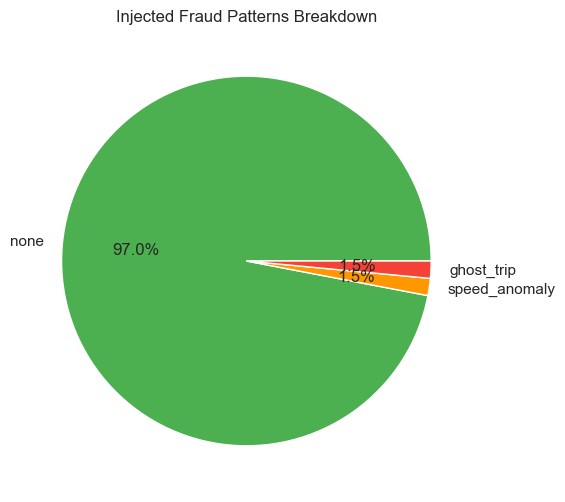

In [14]:
fraud_counts = df['fraud_label'].value_counts()
print("Raw Fraud Label Counts:")
print(fraud_counts)

plt.figure(figsize=(6, 6))
df['fraud_label'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#4CAF50', '#FF9800', '#F44336'])
plt.title('Injected Fraud Patterns Breakdown')
plt.ylabel('')
plt.show()

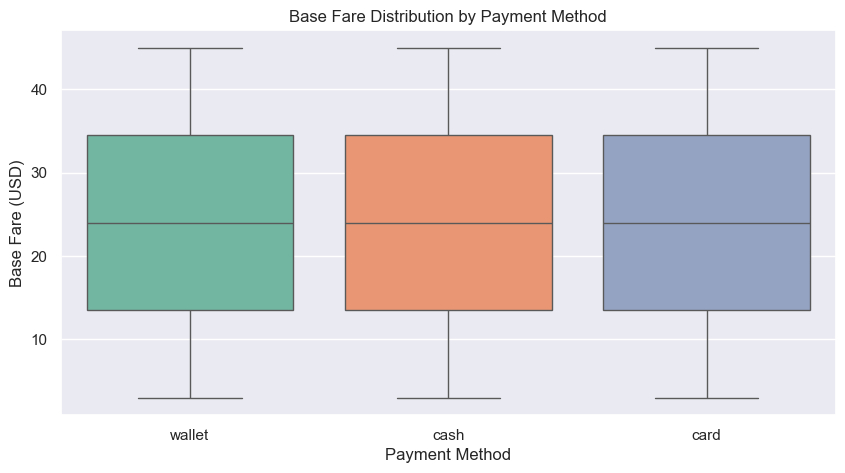

In [15]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='payment_method', y='base_fare_usd', hue='payment_method', palette='Set2', legend=False)
plt.title('Base Fare Distribution by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Base Fare (USD)')
plt.show()